# 01 — Exploratory Data Analysis

This notebook produces the EDA figures and statistics that go onto **Slide 2** (*Problem & Multi-LexSum*) and **Slide 3** (*Data Cleaning + EDA + case_type Grouping*).

**Run this after** `python -m src.cleaning` has produced `data/multilexsum_clean.parquet`.

In [1]:
# Standard imports
import sys
from pathlib import Path

# Make `src` importable when running the notebook from `notebooks/`
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import DATA_DIR, RESULTS_DIR

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

EDA_DIR = RESULTS_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)
print(f'Saving figures to {EDA_DIR}')

Saving figures to E:\mlds\MLDS 414 NLP\final\results\eda


## 1. Load cleaned data

In [2]:
df = pd.read_parquet(DATA_DIR / 'multilexsum_clean.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(2)

Shape: (1602, 15)
Columns: ['case_id', 'source_text', 'n_source_docs', 'long_ref', 'short_ref', 'tiny_ref', 'class_action_sought', 'case_type_raw', 'filing_date', 'court', 'state', 'split', 'source_n_chars', 'source_n_tokens', 'case_type_grouped']


,case_id,source_text,n_source_docs,long_ref,short_ref,tiny_ref,class_action_sought,case_type_raw,filing_date,court,state,split,source_n_chars,source_n_tokens,case_type_grouped
0,PB-WV-0002,Case 3:13-cv-24068 Document /01/13 PageID #: 1...,6,"On October 1, 2013, three same-sex couples and...","On October 1, 2013, three same-sex couples and...","Three same-sex couples, and the minor child of...",False,Public Benefits / Government Services,2013-10-01,None,None,train,257019,40965,Speech & Voting
1,PN-MI-0008,Case 1:13-cv-00469-PLM Doc # /01/13 Page ID#1 ...,5,"On May 1, 2013, two men who were arrested for ...",Two men who were arrested for trespassing on p...,Settlement reached in 2019 for @ACLU case on a...,False,Policing,2013-05-01,None,None,train,273295,42578,Criminal Justice


In [3]:
# Split breakdown
split_counts = df['split'].value_counts().sort_index()
print('Split sizes:')
print(split_counts)
print(f'\nTotal cases: {len(df):,}')

Split sizes:
split
test      312
train    1129
val       161
Name: count, dtype: int64

Total cases: 1,602


## 2. `class_action_sought` distribution (binary classification target)

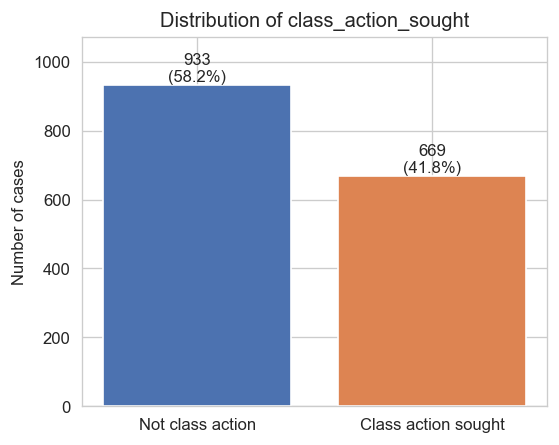

Class balance ratio: 0.717


In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['class_action_sought'].value_counts()
labels = ['Class action sought' if v else 'Not class action' for v in counts.index]
colors = ['#4C72B0', '#DD8452']
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + len(df) * 0.005, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', fontsize=10)
ax.set_ylabel('Number of cases')
ax.set_title('Distribution of class_action_sought')
ax.set_ylim(0, counts.max() * 1.15)
plt.savefig(EDA_DIR / 'class_action_distribution.png')
plt.show()
print(f'Class balance ratio: {counts.min()/counts.max():.3f}')

## 3. `case_type` distribution — raw vs grouped

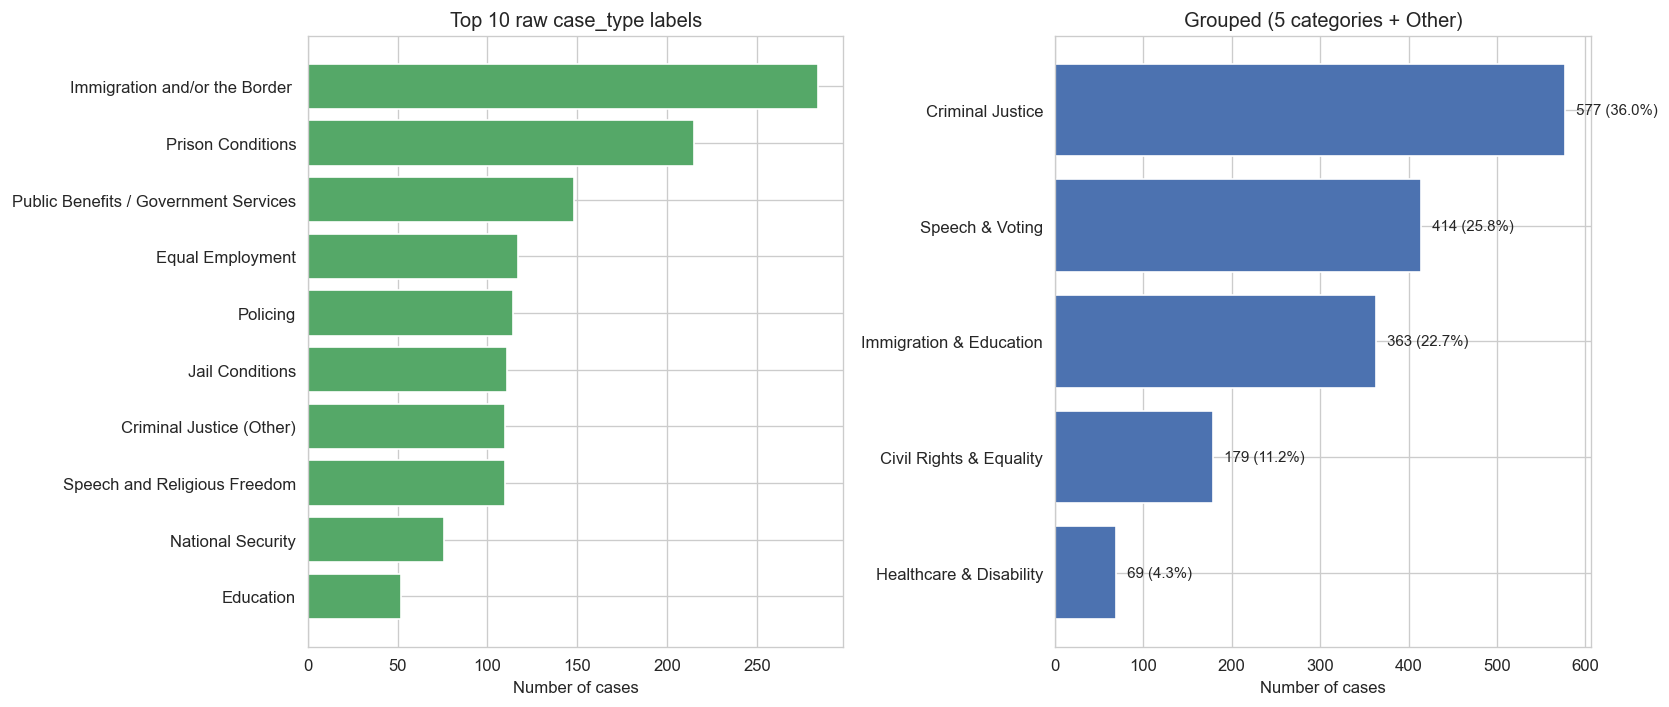

Number of raw labels: 24
'Other' percentage: 0.0%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw labels (top 10)
raw_counts = df['case_type_raw'].value_counts().head(10)
axes[0].barh(raw_counts.index[::-1], raw_counts.values[::-1], color='#55A868')
axes[0].set_title('Top 10 raw case_type labels')
axes[0].set_xlabel('Number of cases')

# Grouped
grp_counts = df['case_type_grouped'].value_counts()
axes[1].barh(grp_counts.index[::-1], grp_counts.values[::-1], color='#4C72B0')
axes[1].set_title(f'Grouped (5 categories + Other)')
axes[1].set_xlabel('Number of cases')
for i, v in enumerate(grp_counts.values[::-1]):
    axes[1].text(v + len(df) * 0.005, i, f' {v} ({v/len(df)*100:.1f}%)',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / 'case_type_distribution.png')
plt.show()

print(f"Number of raw labels: {df['case_type_raw'].nunique()}")
print(f"'Other' percentage: {(df['case_type_grouped']=='Other').mean()*100:.1f}%")

## 4. Source-text length distribution (token count)

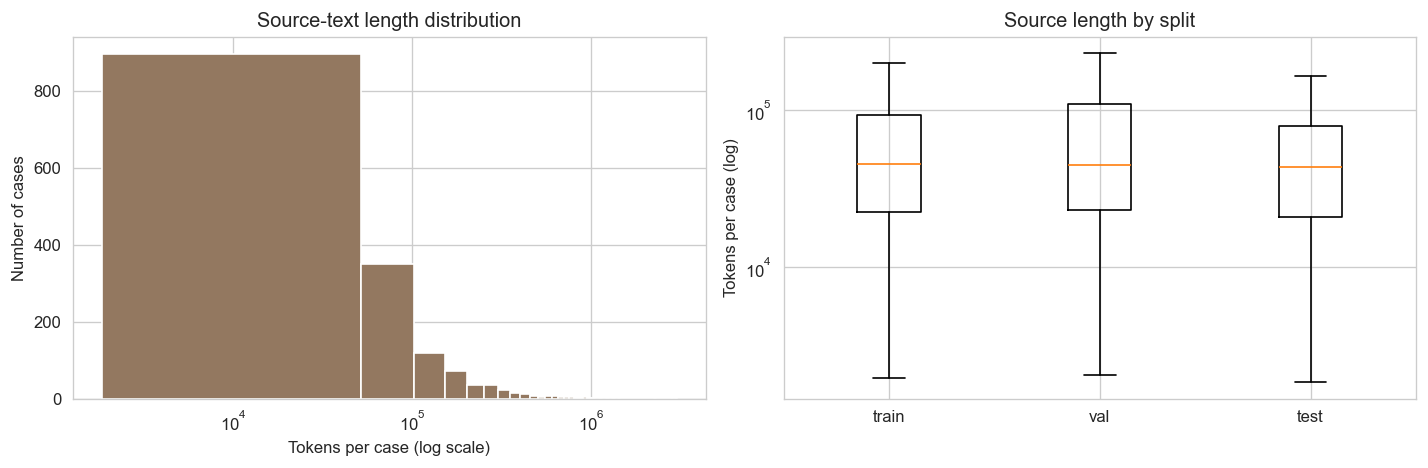

Token stats — min: 1,847  median: 44,789  mean: 94,428  p95: 335,302  max: 3,002,324


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (log x-scale because of long tail)
axes[0].hist(df['source_n_tokens'], bins=60, color='#937860', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Tokens per case (log scale)')
axes[0].set_ylabel('Number of cases')
axes[0].set_title('Source-text length distribution')

# Boxplot by split
data_by_split = [df[df['split']==s]['source_n_tokens'].values for s in ['train', 'val', 'test']]
axes[1].boxplot(data_by_split, tick_labels=['train', 'val', 'test'], showfliers=False)
axes[1].set_yscale('log')
axes[1].set_ylabel('Tokens per case (log)')
axes[1].set_title('Source length by split')

plt.tight_layout()
plt.savefig(EDA_DIR / 'source_length_distribution.png')
plt.show()

tok = df['source_n_tokens']
print(f'Token stats — min: {tok.min():,}  median: {tok.median():,.0f}  '
      f"mean: {tok.mean():,.0f}  p95: {tok.quantile(0.95):,.0f}  max: {tok.max():,}")

## 5. Reference summary length distributions (long / short / tiny)

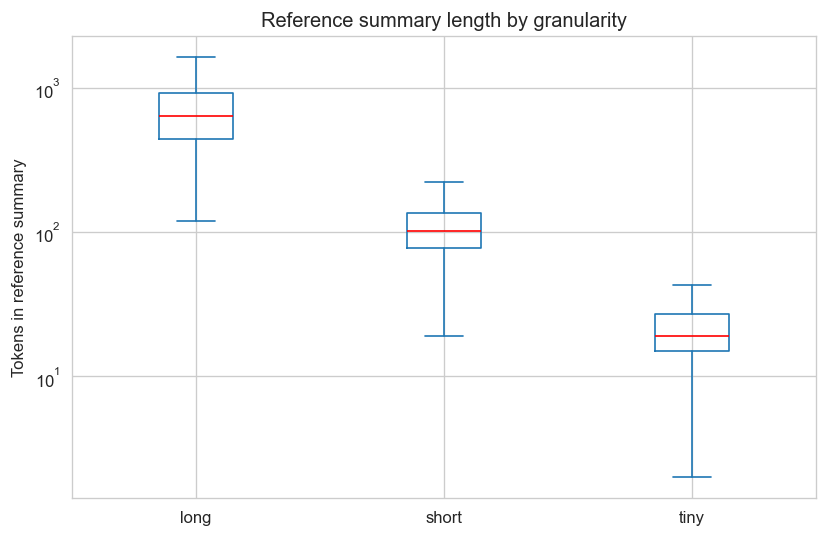

         long   short    tiny
count  1602.0  1602.0  1602.0
mean    772.6   116.0    21.2
std     547.8    62.3     8.2
min     119.0    19.0     2.0
25%     441.2    78.0    15.0
50%     638.0   102.0    19.0
75%     919.0   136.8    27.0
max    8481.0   671.0    43.0


In [7]:
summary_lens = pd.DataFrame({
    'long':  df['long_ref'].str.split().str.len(),
    'short': df['short_ref'].str.split().str.len(),
    'tiny':  df['tiny_ref'].str.split().str.len(),
})

fig, ax = plt.subplots(figsize=(8, 5))
summary_lens.plot.box(ax=ax, showfliers=False, color={'medians': 'red'})
ax.set_ylabel('Tokens in reference summary')
ax.set_yscale('log')
ax.set_title('Reference summary length by granularity')
plt.savefig(EDA_DIR / 'summary_length_by_granularity.png')
plt.show()

print(summary_lens.describe().round(1))

## 6. Cross-tab: `class_action_sought` × `case_type_grouped`

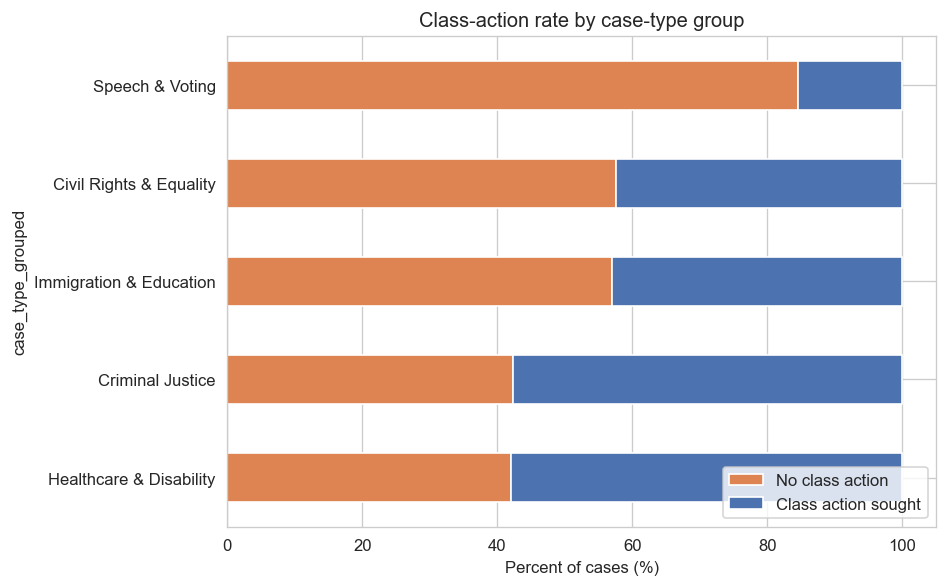

                         No class action  Class action sought
case_type_grouped                                            
Healthcare & Disability             42.0                 58.0
Criminal Justice                    42.3                 57.7
Immigration & Education             57.0                 43.0
Civil Rights & Equality             57.5                 42.5
Speech & Voting                     84.5                 15.5


In [8]:
ct = pd.crosstab(df['case_type_grouped'], df['class_action_sought'],
                 normalize='index') * 100
ct.columns = ['No class action', 'Class action sought']
ct = ct.sort_values('Class action sought', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot.barh(stacked=True, ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_xlabel('Percent of cases (%)')
ax.set_title('Class-action rate by case-type group')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(EDA_DIR / 'classaction_by_casetype.png')
plt.show()

print(ct.round(1))

## 7. Sanity-check: a few sample cases

In [9]:
for split in ['train', 'val', 'test']:
    row = df[df['split']==split].iloc[0]
    print(f"=== {split.upper()} ===")
    print(f"case_id: {row['case_id']}")
    print(f"case_type_raw: {row['case_type_raw']}  →  {row['case_type_grouped']}")
    print(f"class_action_sought: {row['class_action_sought']}")
    print(f"source tokens: {row['source_n_tokens']:,}")
    print(f"long_ref (first 200 chars): {row['long_ref'][:200]}...")
    print(f"tiny_ref: {row['tiny_ref']}")
    print()

=== TRAIN ===
case_id: PB-WV-0002
case_type_raw: Public Benefits / Government Services  →  Speech & Voting
class_action_sought: False
source tokens: 40,965
long_ref (first 200 chars): On October 1, 2013, three same-sex couples and the minor child of one of the couples filed a lawsuit against Kanawha County, West Virginia in the U.S. District Court for the Southern District of West ...
tiny_ref: Three same-sex couples, and the minor child of one of the couples won this same-sex marriage lawsuit in WV

=== VAL ===
case_id: JI-OH-0011
case_type_raw: Juvenile Institution  →  Criminal Justice
class_action_sought: True
source tokens: 7,117
long_ref (first 200 chars): On November 23, 2014, two African-American teenage males filed a lawsuit in the United States District Court for the Southern District of Ohio under 42 U.S.C. §1983 against the Hamilton County Juvenil...
tiny_ref: SW. v. Williams (ongoing) involves incarceration of teenagers without probable cause hearings/determinations in OH.


## Summary statistics for the report (§1)
Numbers to copy into Slide 2 / §1 of README:
- Total cases
- Train / val / test split
- Median source-text tokens
- Class-action rate
- Number of case-type groups

In [10]:
summary = {
    'total_cases': len(df),
    'n_train': int((df['split']=='train').sum()),
    'n_val':   int((df['split']=='val').sum()),
    'n_test':  int((df['split']=='test').sum()),
    'median_source_tokens': int(df['source_n_tokens'].median()),
    'mean_source_tokens':   int(df['source_n_tokens'].mean()),
    'max_source_tokens':    int(df['source_n_tokens'].max()),
    'class_action_rate':    float(df['class_action_sought'].mean()),
    'n_case_type_groups':   int(df['case_type_grouped'].nunique()),
    'other_pct':            float((df['case_type_grouped']=='Other').mean()),
}

import json
(EDA_DIR / 'summary_stats.json').write_text(json.dumps(summary, indent=2))
for k, v in summary.items():
    print(f'{k:<25} {v}')

total_cases               1602
n_train                   1129
n_val                     161
n_test                    312
median_source_tokens      44789
mean_source_tokens        94428
max_source_tokens         3002324
class_action_rate         0.41760299625468167
n_case_type_groups        5
other_pct                 0.0
